In [64]:
# 1. الاستيراد (لضمان عدم ظهور NameError)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [8]:
#read dataset
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv.zip")

In [65]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(253680, 22)


In [66]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0      

In [67]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [69]:
print("\nTarget Distribution:")
print(df["Diabetes_012"].value_counts())


Target Distribution:
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


In [9]:
#duplicates
df = df.drop_duplicates().sample(20000, random_state=42)

In [10]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

In [11]:
#rtrain & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [90]:
# =====================================================
# 3. Data Preprocessing
# =====================================================

print("\n--- Data Shapes ---")
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")


--- Data Shapes ---
Train Shape: (16000, 21)
Test Shape: (4000, 21)


In [91]:
# MODEL 2 — RANDOM FOREST
# =====================================================
# Initializing Random Forest
# Added class_weight='balanced' to handle the imbalanced diabetes labels
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)


In [92]:
# Training the model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# CORRECTED: Get probabilities for ALL classes (required for multi-class ROC AUC)
rf_proba = rf_model.predict_proba(X_test)


# Metrics
print(f"\nAccuracy Score: {accuracy_score(y_test, rf_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# CORRECTED: Using multi_class='ovr' for the 3 categories
print(f"\nROC AUC Score (OVR): {roc_auc_score(y_test, rf_proba, multi_class='ovr'):.4f}")




Accuracy Score: 0.7408

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.77      0.84      3315
         1.0       0.04      0.02      0.03        81
         2.0       0.35      0.66      0.46       604

    accuracy                           0.74      4000
   macro avg       0.43      0.49      0.44      4000
weighted avg       0.81      0.74      0.76      4000


ROC AUC Score (OVR): 0.7311


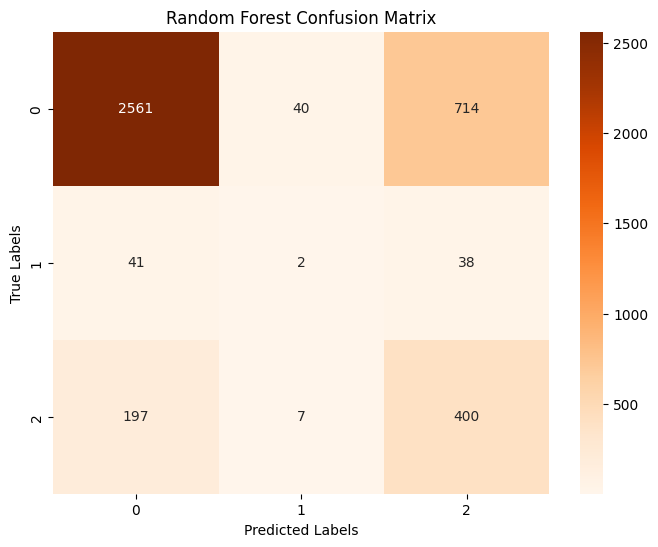

In [93]:
# 1. Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()



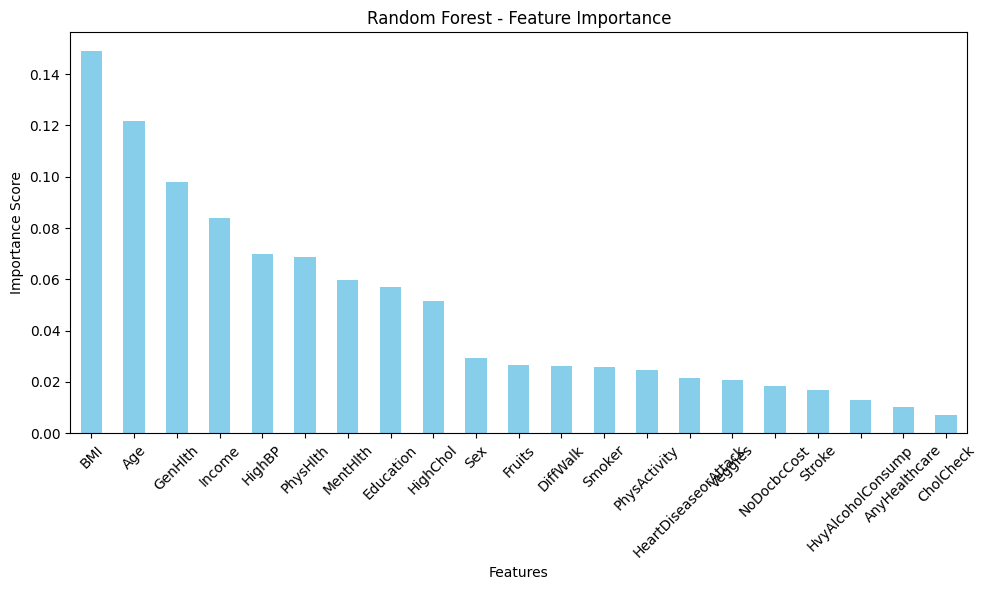

In [94]:
# 2. Feature Importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar', color='skyblue')
plt.title("Random Forest - Feature Importance")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()